# Micro Macro Formulation 1D

**Purpose.** Reproduce the named radiative-transfer experiment with its original computational workflow.

**Distinction.** This notebook is the canonical study; existing code, parameters, outputs, and execution order are unchanged.


#### Riadtive transfer equation 
$$\varepsilon v \cdot \nabla_x f = \left \langle f \right \rangle - f - \varepsilon v, \quad \; x \in [0, 1], \; v \in [-1, 1].$$

Micro-macro formulation:
$$\begin{equation}
    \left\{
    \begin{aligned}
         & \left \langle v \cdot \nabla_{x} g \right \rangle = 0,                                                                               \\
         & \varepsilon v \cdot \nabla_{x} g + v \cdot \nabla_{x} \rho = - g - v, \\
         & \langle g \rangle = 0.
    \end{aligned}
    \right.
\end{equation}$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.append("..")
# import jax
# jax.config.update("jax_platform_name", "cpu")

In [2]:
from solver.least_squares import solve
from configuration.rte_1d_settings import get_config
from utils.quadrature import leggauss

In [ ]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
kn = 1e-2    # rte_config.model.knudsen_number
grid_sizes = rte_config.model.grid_sizes
num_quads = rte_config.model.num_quads
num_x, num_v = grid_sizes
# num_x, num_v = 2, 2
print(f"num_x = {num_x}, num_v = {num_v}")

xmin, xmax = domain["x"]
vmin, vmax = domain["v"]
dx = (xmax - xmin) / num_x
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin - dx / 2, xmax + dx / 2, num_x + 2
)  # cell center + gohst points
# x, xc
quadratures = leggauss(num_v)
mesh_v, weights = quadratures
mesh_v = mesh_v[::-1]  # reverse the order


def fn_l(v):
    return np.ones_like(v)


def fn_r(v):
    return np.zeros_like(v)

num_x = 128, num_v = 128


In [4]:
M, N = num_x, num_v
dofs = M + 1 + (M + 2) * N
matrix_A = np.zeros((dofs, dofs))
rhs = np.zeros((dofs, 1))

In [5]:
for j in range(N):
    v = mesh_v[j][0]
    v_dx = v / dx

    if v > 0:
        block_mat_rho = np.diag([1] + [v_dx] * M) + np.diag(
            [-v_dx] * M, -1
        )  # shape (M + 1, M + 1)

        block_mat_g = np.hstack([
            np.array([kn / 2] + [0] * M)[:, None],
            np.diag([kn / 2] + [kn * v_dx] * M)
            + np.diag([1 - kn * v_dx] * M, -1),
        ])  # shape (M + 1, M + 2)

        rhs[j * (M + 1): (j + 1) * (M + 1), 0] = np.array(
            [fn_l(v)] + [-v] * M
        )

    else:
        block_mat_rho = np.diag([-v_dx] * M + [1]) + np.diag(
            [v_dx] * M, 1
        )  # shape (M + 1, M + 1)

        block_mat_g = np.hstack([
            np.zeros((len(mesh_x), 1)),
            np.diag([kn * v_dx] * M + [kn / 2])
            + np.diag([1 + kn * v_dx] * M, 1)
            + np.diag([0] * (M - 1) + [kn / 2], -1),
        ])  # shape (M + 1, M + 2)

        rhs[j * (M + 1): (j + 1) * (M + 1), 0] = np.array(
            [-v] * M + [fn_r(v)]
        )

    matrix_A[j * (M + 1): (j + 1) * (M + 1), 0: (M + 1)] = block_mat_rho
    matrix_A[
        j * (M + 1): (j + 1) * (M + 1),
        (M + 1) + j * (M + 2): (M + 1) + (j + 1) * (M + 2),
    ] = block_mat_g

for i in range(M + 1):
    index_i = N * (M + 1) + i
    for j in range(N):
        w, v = weights[j][0], mesh_v[j][0]
        wv_dx = w * v / dx
        index_j = (M + 1) + j * (M + 2) + i
        matrix_A[index_i, index_j: index_j + 2] = wv_dx * np.array([1, -1])

for i in range(N):
    v = mesh_v[i][0]
    index_i = N * (M + 1) + (M + 1) + i
    index = (M + 1) + i * (M + 2)
    if v > 0:
        matrix_A[index_i, index: index + 2] = np.array([1, -1])
    else:
        matrix_A[index_i, index + M: index + M + 2] = np.array([-1, 1])

In [6]:
U = solve(matrix_A, rhs)
print(
    f"U shape = {U.shape}, matrix_A shape = {matrix_A.shape}, rhs shape = {rhs.shape}"
)

U shape = (16769, 1), matrix_A shape = (16769, 16769), rhs shape = (16769, 1)


In [7]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (rhs.nbytes / 1024**2))

Matrix A 内存 2145.38 MB
Vector b 内存 0.13 MB


In [8]:
np.abs(matrix_A @ U - rhs).mean()

3.2685616179702716e-09

In [9]:
rho_vector = U[: len(mesh_x)]  # shape (M + 1, 1)
g_vector = U[len(mesh_x):].squeeze()
g_matrix = g_vector.reshape((N, M + 2)).T  # shape (M + 2, N)
avg = g_matrix @ weights
print(f"{np.abs(avg).mean()}")

2.1541259054291828e-10


In [10]:
f_numerical = rho_vector + kn * (g_matrix[:-1, :] + g_matrix[1:, :]) / 2
print(kn)

1.0


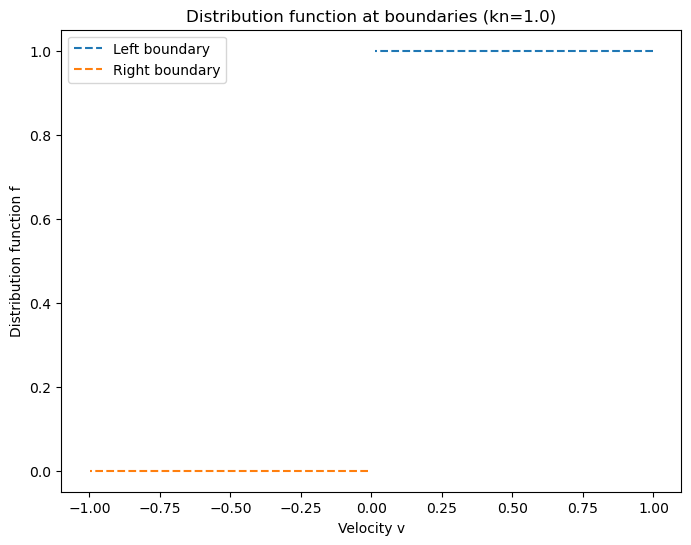

In [11]:
v1d = mesh_v.flatten()  # shape (num_v,)
Fl = f_numerical[0, 1:-1][v1d[1:-1] > 0]
Vl = v1d[1:-1][v1d[1:-1] > 0]

Fr = f_numerical[-1, 1:-1][v1d[1:-1] < 0]
Vr = v1d[1:-1][v1d[1:-1] < 0]


fig = plt.figure(figsize=(8, 6))
ax = plt.plot(Vl, Fl, "--", label="Left boundary")
ax = plt.plot(Vr, Fr, "--", label="Right boundary")
ax = plt.xlabel("Velocity v")
ax = plt.ylabel("Distribution function f")
ax = plt.title(f"Distribution function at boundaries (kn={kn})")
ax = plt.legend()

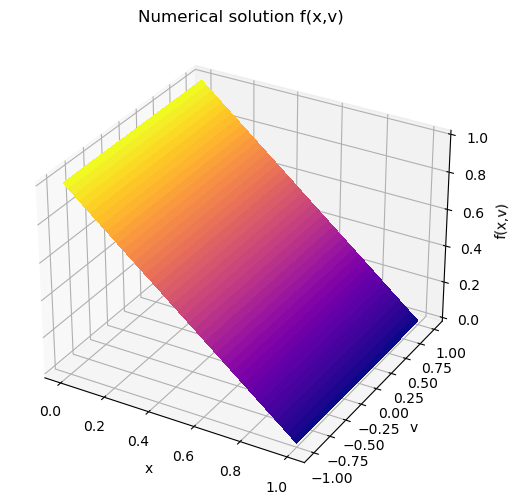

In [12]:
X, V = np.meshgrid(mesh_x, mesh_v, indexing="ij")
F_hat = f_numerical

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F_hat, cmap="plasma",
                         linewidth=0, antialiased=False)
ax1.set_xlabel("x")
ax1.set_ylabel("v")
ax1.set_zlabel("f(x,v)")
ax1.set_title("Numerical solution f(x,v)")
plt.show()

findfont: findfont: 

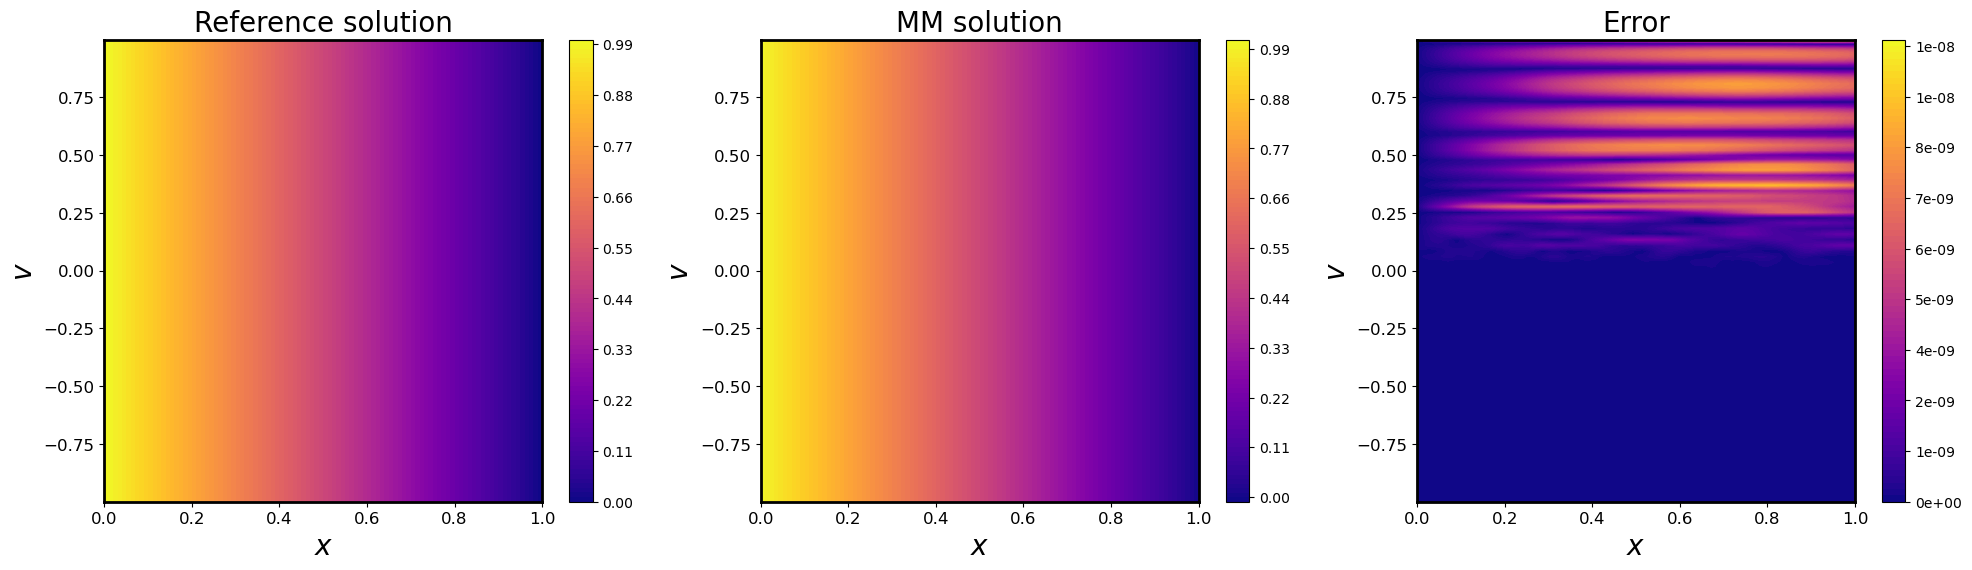

In [13]:
X, V = np.meshgrid(mesh_x, mesh_v)
F = 1.0 - X
F_hat = f_numerical.T

font_format = {"size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, V, F_hat, 100, cmap="plasma")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("MM solution", font_format)
# # line width of four axises
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="plasma")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# # line width of four axises
ax3.spines["bottom"].set_linewidth(2)
ax3.spines["left"].set_linewidth(2)
ax3.spines["right"].set_linewidth(2)
ax3.spines["top"].set_linewidth(2)
plt.show()
plt.close()

In [14]:
rho_numerical = rho_vector.squeeze()
print(f"l2 error = {np.linalg.norm(f_numerical.T - F):.2e}")
print(rho_vector.shape)

l2 error = 3.76e-07
(129, 1)


In [15]:
# np.savez(
#     f"../data/rte1d_ex1_mm_{kn:.2e}.npz",
#     x=mesh_x,
#     v=mesh_v,
#     rho=rho_numerical,
#     f=f_numerical,
# )